In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.DataFrame(pd.read_excel("D:/Masterarbeit/Data/RNAz_Data_Excel/sissi.xlsx"))
new_df = df.drop(['Sequences', 'Columns', 'File', 'SVM RNA-class probability'], axis=1)
new_df.head(10)

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value
0,88.56,0.33271,0.49297,-158.98,-89.35,-85.71,-3.63,2.35,-4.98,0.56,-0.51
1,87.03,0.37237,0.47679,-143.04,-88.69,-83.58,-5.12,2.40,-3.58,0.62,-0.51
2,88.15,0.34519,0.50339,-175.00,-109.84,-105.98,-3.86,2.43,-7.57,0.63,-0.51
3,88.53,0.33514,0.45837,-142.09,-79.41,-75.35,-4.06,2.37,-3.96,0.56,-0.51
4,88.63,0.33170,0.51272,-166.38,-109.89,-105.98,-3.91,2.24,-5.19,0.66,-0.51
5,87.80,0.35132,0.49504,-156.16,-100.00,-95.11,-4.88,2.44,-5.36,0.64,-0.51
6,87.54,0.36054,0.46915,-151.43,-85.51,-81.01,-4.50,2.49,-5.23,0.56,-0.51
7,85.90,0.40009,0.47768,-157.45,-82.41,-77.57,-4.84,2.42,-6.65,0.52,-0.51
8,87.78,0.35122,0.44766,-141.66,-80.46,-75.97,-4.50,2.28,-5.66,0.57,-0.51
9,88.20,0.34545,0.47778,-157.35,-106.12,-99.98,-6.14,2.48,-6.16,0.67,-0.51


In [3]:
new_df[['Mean pairwise identity',
        'Shannon entropy','G+C content',
        'Mean single sequence MFE',	
        'Consensus MFE','Energy contribution',
        'Covariance contribution',
        'Combinations/Pair',
        'Mean z-score',
        'Structure conservation index',
        'SVM decision value',
        'SVM RNA-class probability']].describe()

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02
mean,87.445100,0.361246,0.488293,-156.546600,-89.324900,-84.676400,-4.648700,2.416200,-5.289000,0.569700,-5.100000e-01,2.876970e-01
std,0.756851,0.017965,0.026755,10.126071,12.603013,12.269277,1.030818,0.081213,0.998547,0.063619,3.347448e-16,5.021173e-16
min,84.960000,0.326170,0.421830,-176.760000,-129.810000,-124.680000,-7.340000,2.110000,-7.570000,0.390000,-5.100000e-01,2.876970e-01
25%,86.980000,0.348790,0.469832,-162.980000,-97.665000,-92.587500,-5.152500,2.367500,-6.012500,0.530000,-5.100000e-01,2.876970e-01
50%,87.505000,0.360565,0.487960,-157.570000,-88.920000,-84.910000,-4.650000,2.420000,-5.230000,0.570000,-5.100000e-01,2.876970e-01
75%,87.977500,0.372213,0.507380,-148.492500,-80.692500,-76.052500,-3.900000,2.472500,-4.515000,0.610000,-5.100000e-01,2.876970e-01
max,88.900000,0.419530,0.546100,-131.740000,-56.810000,-53.500000,-1.970000,2.590000,-3.210000,0.750000,-5.100000e-01,2.876970e-01


In [176]:
X = new_df.drop(columns=['SVM RNA-class probability'])
y = new_df['SVM RNA-class probability']

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=36)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [178]:
model = RandomForestRegressor(random_state=36)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=36)

In [179]:
y_pred = model.predict(X_test_scaled)

In [180]:
# Schwellenwert definieren (z. B. Median der Zielvariable)
threshold = y.median()

# Zielvariable binär machen
y_test_binary = (y_test >= threshold).astype(int)
y_pred_binary = (y_pred >= threshold).astype(int)

# ROC-AUC neu berechnen
roc_auc = roc_auc_score(y_test_binary, y_pred_binary)
print(f"ROC-AUC: {roc_auc:.4f}")


ROC-AUC: 1.0000


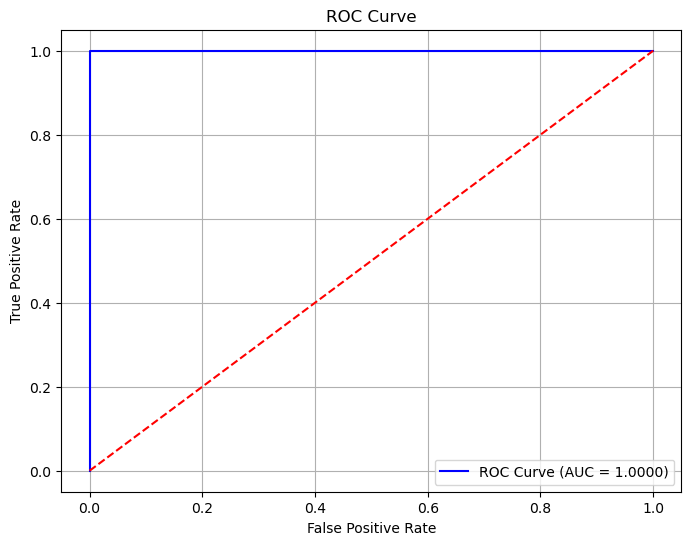

In [181]:
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_binary)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [182]:
tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_binary).ravel()

# Werte der Confusion-Matrix
matrix = np.array([[tn, fp], [fn, tp]])

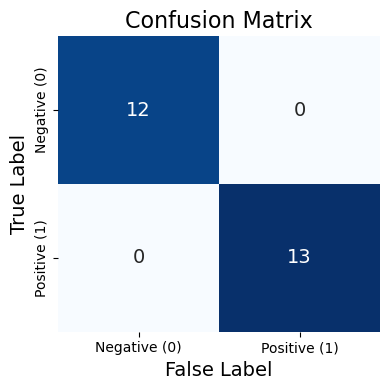

In [183]:
tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_binary).ravel()

# Werte der Confusion-Matrix
matrix = np.array([[tn, fp], [fn, tp]])

# Achsenbeschriftungen
labels = ["Negative (0)", "Positive (1)"]
matrix_labels = np.array([["TN", "FP"], ["FN", "TP"]])

# Heatmap erstellen
plt.figure(figsize=(4, 4))
ax = sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, 
                 xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})

# Titel und Achsenbeschriftungen
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("False Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.tight_layout()
plt.show()
